# Trust Region Bayesian Optimization with TuRBO

[_Link to Tutorial on BoTorch_](https://botorch.org/docs/tutorials/turbo_1/)

_Drew Gjerstad_

**Includes content from BoTorch's documentation.**

In this tutorial, we focus on implementing **Trust Region Bayesian Optimization** ([TuRBO](https://proceedings.neurips.cc/paper/2019/file/6c990b7aca7bc7058f5e98ea909e924b-Paper.pdf)) in a closed loop in BoTorch. In these examples, we will use one trust region (TuRBO-1) and two different acquisition functions: parallel expected improvement (qEI) and Thompson sampling (TS). We will apply the implementation to the 20-dimensional Ackley function on the domain $[-5, 10]^{20}$. We find that TuRBO-1 performs better than both qEI and Sobol. Keep in mind that since BoTorch focuses on maximization, we will need to switch the sign of the objective to find the minimum of the Ackley function:

\begin{equation*}
    -f(x) \rightarrow \max_{x}-f(x) = 0
\end{equation*}

## Setup
First, we load the necessary dependencies and set keyword arguments for tensors.

In [1]:
# Load Dependencies
import os
import math
import warnings
from dataclasses import dataclass

import torch
from botorch.acquisition import qExpectedImprovement, qLogExpectedImprovement
from botorch.exceptions import BadInitialCandidatesWarning, NumericsWarning
from botorch.fit import fit_gpytorch_mll
from botorch.generation import MaxPosteriorSampling
from botorch.models import SingleTaskGP
from botorch.optim import optimize_acqf
from botorch.test_functions import Ackley
from botorch.utils.transforms import unnormalize
from torch.quasirandom import SobolEngine

import gpytorch
from gpytorch.constraints import Interval
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings("ignore", category=BadInitialCandidatesWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SMOKE_TEST = os.environ.get("SMOKE_TEST")

# Tensor Keyword Arguments
tkwargs = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.double,
}

/Users/drewgjerstad/miniconda3/envs/bo-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The Ackley Function
Let's review our objective: optimize the 20-dimensional Ackley function. The Ackley function is a popular function for testing the capabilities for novel optimization approaches and is given by

\begin{equation*}
    f(x_1,\dots,x_d) = -20\exp(-0.2\sqrt{\frac{1}{d}\sum_{j=1}^{d}x_j^2}) -
    \exp(\frac{1}{d}\sum_{j=1}^{d}\cos(2\pi x_j)) + 20 + e
\end{equation*}

on the domain $[-5, 10]^{20}$. Note that the global optimal value of 0 is found at $x_1 = \dots = x_d = 0$ (the "origin"). As mentioned above, we will flip the sign of the Ackley function since BoTorch assumes maximization.

In [2]:
# Ackley Function
ackley = Ackley(dim=20, negate=True).to(**tkwargs)
ackley.bounds[0, :].fill_(-5)
ackley.bounds[1, :].fill_(10)
dim = ackley.dim
lb, ub = ackley.bounds

# Hyperparameters
BATCH_SIZE = 4
N_INITIAL = 2 * dim
MAX_CHOLESKY_SIZE = float("inf")    # always use Cholesky

# Define Objective Evaluation
def objective(x):
    """
    This is a helper function that we will use to unnormalize and evaluate a
    point `x`.
    """
    return ackley(unnormalize(x, ackley.bounds))

## Introduction to TuRBO
The TuRBO algorithm must maintain a state for the trust region, tracking the length of the trust region, success and failure counters, success and failure tolerance, among other attributes. The author of this tutorial uses a dataclass to store this information and then update it after every batch evaluation. Note that we will assume the domain is scaled to $[0,1]^d$ and that the batch size is constant.

In [3]:
# TuRBO State

@dataclass
class TurboState:
    dim: int
    batch_size: int
    length: float = 0.8
    length_min: float = 0.5 ** 7
    length_max: float = 1.6
    failure_counter: int = 0
    failure_tol: int = float("nan")     # post-initialized
    success_counter = 0
    success_tol: int = 10               # original paper uses 3
    best_value: float = -float("inf")
    restart_triggered: bool = False

    def __post_init__(self):
        self.failure_tol = math.ceil(
            max([4.0 / self.batch_size, float(self.dim) / self.batch_size])
        )


def update_state(state, Y_next):
    if max(Y_next) > state.best_value + 1e-3 * math.fabs(state.best_value):
        state.success_counter +=1
        state.failure_counter = 0
    else:
        state.success_counter = 0
        state.failure_counter += 1
    
    if state.success_counter == state.success_tol:
        # Expand trust region
        state.length = min(2.0 * state.length, state.length_max)
        state.success_counter = 0
    elif state.failure_counter == state.failure_tol:
        # Shrink trust region
        state.length /= 2.0
        state.failure_counter = 0
    
    # Update best value
    state.best_value = max(state.best_value, max(Y_next).item())

    # Trigger restart if necessary
    if state.length < state.length_min:
        state.restart_triggered = True
    
    return state

In [4]:
# Inspect State
state = TurboState(dim=dim, batch_size=BATCH_SIZE)
print(state)

TurboState(dim=20, batch_size=4, length=0.8, length_min=0.0078125, length_max=1.6, failure_counter=0, failure_tol=5, success_tol=10, best_value=-inf, restart_triggered=False)


## Generate Initial Points
Next, we will define a function to generate a set of initial points used to start the optimization loop.

In [5]:
# Generate Initial Points
def get_initial_points(dim, n_points, seed=0):
    sobol = SobolEngine(dimension=dim, scramble=True, seed=seed)
    X_init = sobol.draw(n=n_points).to(**tkwargs)
    return X_init

## Acquisition Function (Generating Batches during Optimization)
To acquire points during the optimization loop, we will define a function that generates a batch of points using either Thompson sampling (TS) or parallel expected improvement (qEI) via the `acqf` argument. Note that we assume the domain of the observations are $[0, 1]^d$ (i.e., not the Ackley's domain). In addition, we will use the current Turbo state and probabilistic GP model from previous observations to aid in the acquisition of new observations.

In [6]:
# Generate New Batches
def generate_batch(state, model, X, Y, batch_size, n_candidates=None,
                   n_restarts=10, raw_samples=512, acqf="ts"):
    # `model`: GP model
    # `X`: evaluated points on the domain [0, 1]^d
    # `Y`: function values
    # `n_candidates`: number of candidates for Thompson sampling
    # `acqf`: "ei" or "ts" for expected improvement and Thompson sampling, resp.

    assert acqf in ("ts", "ei")
    assert X.min() >= 0.0 and X.max() <= 1.0 and torch.all(torch.isfinite(Y))

    if n_candidates is None:
        n_candidates = min(5_000, max(2_000, 200 * X.shape[-1]))
    
    # Scale trust region to be proportional to lengthscales
    x_center = X[Y.argmax(), :].clone()
    weights = model.covar_module.base_kernel.lengthscale.squeeze().detach()
    weights /= weights.mean()
    weights /= torch.prod(weights.pow(1.0 / weights.numel()))
    tr_lb = torch.clamp(x_center - weights * state.length / 2.0, 0.0, 1.0)
    tr_ub = torch.clamp(x_center + weights * state.length / 2.0, 0.0, 1.0)

    if acqf == "ts":
        # Acquisition Function --> Thompson sampling (TS)
        dim = X.shape[-1]
        sobol = SobolEngine(dim, scramble=True)
        pert = sobol.draw(n_candidates).to(**tkwargs)
        pert = tr_lb + (tr_ub - tr_lb) * pert

        # Create Perturbation mask
        prob_perturb = min(20.0 / dim, 1.0)
        mask = torch.rand(n_candidates, dim, **tkwargs) <= prob_perturb
        ind = torch.where(mask.sum(dim=1) == 0)[0]
        mask[ind, torch.randint(0, dim - 1, size=(len(ind),), device="cpu")] = 1

        # Create Candidate Points from Perturbations and Mask
        X_cand = x_center.expand(n_candidates, dim).clone()
        X_cand[mask] = pert[mask]

        # Sample Candidate Points
        thompson_sampling = MaxPosteriorSampling(model=model, replacement=False)
        with torch.no_grad():
            # No gradients required when using TS
            X_next = thompson_sampling(X_cand, num_samples=batch_size)

    elif acqf == "ei":
        # Acquisition Function --> Parallel Expected Improvement
        ei = qExpectedImprovement(model, Y.max())
        X_next, acq_val = optimize_acqf(
            ei,
            bounds=torch.stack([tr_lb, tr_ub]),
            q=batch_size,
            num_restarts=n_restarts,
            raw_samples=raw_samples,
        )

    return X_next

## Define the Optimization Loop
Now that we can sample an initial set as well as batches during the optimization loop, we can now define our optimization loop. This loop will run one instance of TuRBO-1 with Thompson sampling until convergence.

Some background about TuRBO-1 is that it is a local optimizer which can be used for problems with fixed evaluation budgets (with restarts). Once the algorithm converges, `state["restart_triggered"]` will be True and the run should be aborted. If one wants to perform more evaluations then simply generate a new set of initial points and keep generating batches until convergence or until the evaluation budget is reached. Finally, keep in mind that the evaluations from previous instances are discarded upon restart.

In [7]:
# Optimization Loop

# Initial Data Points
X_turbo = get_initial_points(dim, N_INITIAL)
Y_turbo = torch.tensor(
    [objective(x) for x in X_turbo], **tkwargs
).unsqueeze(-1)

# Initialize TuRBO State
state = TurboState(
    dim=dim, batch_size=BATCH_SIZE, best_value=max(Y_turbo).item()
)

# Set Hyperparameters
N_RESTARTS = 10 if not SMOKE_TEST else 2
RAW_SAMPLES = 512 if not SMOKE_TEST else 4
N_CANDIDATES = min(5_000, max(2_000, 200 * dim)) if not SMOKE_TEST else 4

# Set Seed
torch.manual_seed(0)

# Run Loop (until convergence)
while not state.restart_triggered:
    # Fit GP Model
    train_Y = (Y_turbo - Y_turbo.mean()) / Y_turbo.std()
    likelihood = GaussianLikelihood(noise_constraint=Interval(1e-8, 1e-3))
    covar_module = ScaleKernel(  # use same lengthscale prior as paper
        MaternKernel(
            nu=2.5,
            ard_nums_dims=dim,
            lengthscale_constraint=Interval(0.005, 4.0)
        )
    )
    model = SingleTaskGP(
        X_turbo, train_Y, covar_module=covar_module, likelihood=likelihood
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)

    # Perform Fitting and Acquisition Function Optimization w/ Cholesky
    with gpytorch.settings.max_cholesky_size(MAX_CHOLESKY_SIZE):
        # Fit Model
        fit_gpytorch_mll(mll)

        # Create Batch
        X_next = generate_batch(
            state=state,
            model=model,
            X=X_turbo,
            Y=train_Y,
            batch_size=BATCH_SIZE,
            n_candidates=N_CANDIDATES,
            n_restarts=N_RESTARTS,
            raw_samples=RAW_SAMPLES,
            acqf="ts",
        )
    
    # Evaluate Objective at New Locations
    Y_next = torch.tensor(
        [objective(x) for x in X_next], **tkwargs
    ).unsqueeze(-1)

    # Update State
    state = update_state(state=state, Y_next=Y_next)

    # Augment Data
    X_turbo = torch.cat((X_turbo, X_next), dim=0)
    Y_turbo = torch.cat((Y_turbo, Y_next), dim=0)

# Print Final Status
print(f"{len(X_turbo)}) Best value: {state.best_value:.2e}")

500) Best value: -1.39e-01


## Compare TuRBO to qLogEI and qEI
In the next two code cells, we will compare TuRBO to qLogEI and qEI. After that we will make plots comparing their progress and outcome.

In [8]:
# GP-LogEI
torch.manual_seed(0)

X_logei = get_initial_points(dim, N_INITIAL)
Y_logei = torch.tensor(
    [objective(x) for x in X_logei], **tkwargs
).unsqueeze(-1)

# Cap Evaluations when Running Smoke Test
max_evals = min(len(Y_turbo), N_INITIAL + 2 * BATCH_SIZE) if SMOKE_TEST else len(Y_turbo)

# Loop
while len(Y_logei) < max_evals:
    # Fit Model
    train_Y = (Y_logei - Y_logei.mean()) / Y_logei.std()
    likelihood = GaussianLikelihood(noise_constraint=Interval(1e-8, 1e-3))
    model = SingleTaskGP(X_logei, train_Y, likelihood=likelihood)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # Create Batch
    log_ei = qLogExpectedImprovement(model, train_Y.max())
    candidate, acq_value = optimize_acqf(
        log_ei,
        bounds=torch.stack(
            [
                torch.zeros(dim, **tkwargs),
                torch.ones(dim, **tkwargs)
            ]
        ),
        q=BATCH_SIZE,
        num_restarts=N_RESTARTS,
        raw_samples=RAW_SAMPLES,
    )
    
    # Evaluate Objective at New Locations
    Y_next = torch.tensor(
        [objective(x) for x in candidate], **tkwargs
    ).unsqueeze(-1)

    # Augment Data
    X_logei = torch.cat((X_logei, candidate), dim=0)
    Y_logei = torch.cat((Y_logei, Y_next), dim=0)

# Print Final Status
print(f"{len(X_logei)}) Best value: {Y_logei.max().item():.2e}")

500) Best value: -3.11e+00


In [9]:
# GP-EI
torch.manual_seed(0)

# Suppress Numeric Warning for qEI
warnings.filterwarnings("ignore", category=NumericsWarning)

X_ei = get_initial_points(dim, N_INITIAL)
Y_ei = torch.tensor(
    [objective(x) for x in X_ei], **tkwargs
).unsqueeze(-1)

# Loop
while len(Y_ei) < len(Y_turbo):
    train_Y = (Y_ei - Y_ei.mean()) / Y_ei.std()
    likelihood = GaussianLikelihood(noise_constraint=Interval(1e-8, 1e-3))
    model = SingleTaskGP(X_ei, train_Y, likelihood=likelihood)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # Create Batch
    ei = qExpectedImprovement(model, train_Y.max())
    candidate, acq_value = optimize_acqf(
        ei,
        bounds=torch.stack(
            [
                torch.zeros(dim, **tkwargs),
                torch.ones(dim, **tkwargs)
            ]
        ),
        q=BATCH_SIZE,
        num_restarts=N_RESTARTS,
        raw_samples=RAW_SAMPLES,
    )

    # Evaluate Objective at New Locations
    Y_next = torch.tensor(
        [objective(x) for x in candidate], **tkwargs
    ).unsqueeze(-1)

    # Augment Data
    X_ei = torch.cat((X_ei, candidate), dim=0)
    Y_ei = torch.cat((Y_ei, Y_next), dim=0)

# Print Final Status
print(f"{len(X_ei)}) Best value: {Y_ei.max().item():.2e}")

500) Best value: -9.11e+00


## Try Out Sobol Sampling
Before we plot the progress and outcome to compare TuRBO against parallel expected improvement (qEI) and parallel log expected improvement (qLogEI), we will also use Sobol sampling to find the optimum. This will also be included in the comparison plot.

In [10]:
# Sobol

X_Sobol = (
    SobolEngine(dim, scramble=True, seed=0)
    .draw(len(X_turbo))
    .to(**tkwargs)
)
Y_Sobol = torch.tensor(
    [objective(x) for x in X_Sobol], **tkwargs
).unsqueeze(-1)

print(f"{len(X_Sobol)}) Best value: {Y_Sobol.max().item():.2e}")

500) Best value: -1.06e+01


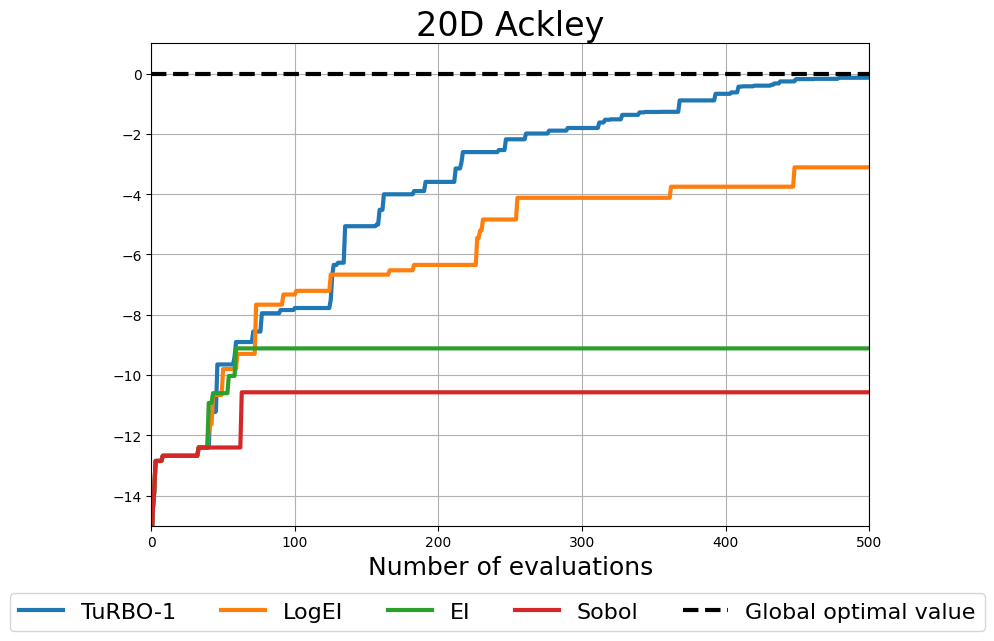

In [11]:
# Plot Progress and Outcome
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

%matplotlib inline

names = ["TuRBO-1", "LogEI", "EI", "Sobol"]
runs = [Y_turbo, Y_logei, Y_ei, Y_Sobol]
fig, ax = plt.subplots(figsize=(8, 6))

for name, run in zip(names, runs):
    fx = np.maximum.accumulate(run.cpu())
    plt.plot(fx, marker="", lw=3)

plt.plot([0, len(Y_turbo)], [ackley.optimal_value, ackley.optimal_value],
         "k--", lw=3)
plt.xlabel("Function value", fontsize=18)
plt.xlabel("Number of evaluations", fontsize=18)
plt.title("20D Ackley", fontsize=24)
plt.xlim([0, len(Y_turbo)])
plt.ylim([-15, 1])

plt.grid(True)
plt.tight_layout()
plt.legend(
    names + ["Global optimal value"],
    loc="lower center",
    bbox_to_anchor=(0, -0.08, 1, 1),
    bbox_transform=plt.gcf().transFigure,
    ncol=5,
    fontsize=16,
)
plt.show()